# Avaliação do KNN em Dados Artificiais de Ultrassom

Este notebook demonstra passo a passo:

1. **Carregamento** do dataset artificial gerado por `generate_artificial_dataset.py`
2. **Exploração** dos dados ruidosos e suas propriedades estatísticas
3. **Carregamento** do checkpoint do modelo KNN treinado por `knn_classifier.py`
4. **Predições** nas medições artificialmente perturbadas
5. **Métricas** de desempenho do regressor sobre os dados ruidosos

---

### Contexto

- O dataset artificial foi gerado multiplicando cada ponto original por um vetor de **ganhos aleatórios** amostrados de $\mathcal{N}(\mu=1, \sigma=0.002)$, simulando variações de medição.
- O modelo KNN (k=1) foi treinado nos dados **originais** e avaliado aqui sobre os dados perturbados.
- As métricas mostram quão bem o modelo generaliza para medições com ruído realista.

## 1. Imports e Configuração

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from pathlib import Path
from sklearn import metrics

DATA_DIR = Path('.')
CHECKPOINT_PATH = DATA_DIR / 'knn_checkpoint.joblib'

print('Bibliotecas carregadas com sucesso.')
print(f'Diretório de trabalho: {DATA_DIR.resolve()}')

Bibliotecas carregadas com sucesso.
Diretório de trabalho: /home/mvendramini/clones/master/UltrasoundClassifcation/erros


## 2. Carregamento do Dataset Artificial

O arquivo `artificial_<timestamp>.h5` foi gerado por `generate_artificial_dataset.py`.
Selecionamos automaticamente o arquivo mais recente na pasta.

In [2]:
# Localiza todos os arquivos artificiais e seleciona o mais recente
artificial_files = sorted(DATA_DIR.glob('artificial_*.h5'))

if not artificial_files:
    raise FileNotFoundError(
        'Nenhum arquivo artificial_*.h5 encontrado.\n'
        'Execute: python generate_artificial_dataset.py'
    )

art_file = artificial_files[-1]
print(f'Arquivo selecionado: {art_file.name}')
print(f'Total de arquivos artificiais encontrados: {len(artificial_files)}')

Arquivo selecionado: artificial_20260223_141210.h5
Total de arquivos artificiais encontrados: 1


In [3]:
# Abre o arquivo e exibe metadados
with h5py.File(art_file, 'r') as f:
    print('=== Atributos do arquivo ===')
    for k, v in f.attrs.items():
        print(f'  {k:30s}: {v}')

    print('\n=== Datasets disponíveis ===')
    for name in f.keys():
        ds = f[name]
        print(f'  {name:30s}: shape={ds.shape}, dtype={ds.dtype}')

    # Carrega os dados artificiais (ruidosos) e os originais
    X_art  = np.array(f['measurements'])           # dados ruidosos
    y_art  = np.array(f['heights'])                # alturas correspondentes
    X_orig = np.array(f['original_measurements'])  # dados originais (sem ruído)
    y_orig = np.array(f['original_heights'])       # alturas originais

    n_artificial_per_orig = int(f.attrs['n_artificial_per_original'])
    gain_mean = float(f.attrs['gain_mean'])
    gain_std  = float(f.attrs['gain_std'])
    gain_dist = str(f.attrs['gain_distribution'])

print(f'\nX_art  shape : {X_art.shape}  (dados ruidosos)')
print(f'y_art  shape : {y_art.shape}')
print(f'X_orig shape : {X_orig.shape}  (dados originais)')
print(f'y_orig shape : {y_orig.shape}')

=== Atributos do arquivo ===
  description                   : Dataset artificial gerado a partir de medições de ultrassom. Cada ponto original foi perturbado por ganhos aleatórios element-wise.
  gain_distribution             : normal
  gain_mean                     : 1.0
  gain_std                      : 0.002
  n_artificial_per_original     : 5
  n_artificial_total            : 3030
  n_original                    : 606
  source_files                  : model_compound_4_10_34_1_interface.h5, model_compound_4_10_68_1_interface.h5
  timestamp                     : 20260223_141210

=== Datasets disponíveis ===
  heights                       : shape=(3030,), dtype=float64
  measurements                  : shape=(3030, 16), dtype=float64
  original_heights              : shape=(606,), dtype=float64
  original_measurements         : shape=(606, 16), dtype=float64

X_art  shape : (3030, 16)  (dados ruidosos)
y_art  shape : (3030,)
X_orig shape : (606, 16)  (dados originais)
y_orig shape :

## 3. Exploração dos Dados Artificiais

Verificamos a distribuição das alturas e a magnitude do ruído introduzido.

In [4]:
# Distribuição das alturas no dataset artificial
unique_heights, counts = np.unique(y_art, return_counts=True)

print(f'Alturas únicas no dataset artificial: {len(unique_heights)}')
print(f'Amostras por altura (devem ser múltiplos de {n_artificial_per_orig}):')
df_counts = pd.DataFrame({'height': unique_heights, 'count': counts})
print(df_counts.to_string(index=False))

Alturas únicas no dataset artificial: 101
Amostras por altura (devem ser múltiplos de 5):
 height  count
   25.0     30
   26.0     30
   27.0     30
   28.0     30
   29.0     30
   30.0     30
   31.0     30
   32.0     30
   33.0     30
   34.0     30
   35.0     30
   36.0     30
   37.0     30
   38.0     30
   39.0     30
   40.0     30
   41.0     30
   42.0     30
   43.0     30
   44.0     30
   45.0     30
   46.0     30
   47.0     30
   48.0     30
   49.0     30
   50.0     30
   51.0     30
   52.0     30
   53.0     30
   54.0     30
   55.0     30
   56.0     30
   57.0     30
   58.0     30
   59.0     30
   60.0     30
   61.0     30
   62.0     30
   63.0     30
   64.0     30
   65.0     30
   66.0     30
   67.0     30
   68.0     30
   69.0     30
   70.0     30
   71.0     30
   72.0     30
   73.0     30
   74.0     30
   75.0     30
   76.0     30
   77.0     30
   78.0     30
   79.0     30
   80.0     30
   81.0     30
   82.0     30
   83.0     30
   84.0   

In [ ]:
# Visualiza a magnitude do ruído: razão entre dados artificiais e originais
# Para cada ponto original i, os N artificiais são i*N_ART ... i*N_ART + N_ART-1
N = X_orig.shape[0]
N_ART = n_artificial_per_orig

# Ratio artificial / original para todos os pontos e canais
ratios = []
for i in range(N):
    for j in range(N_ART):
        # evita divisão por zero
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(X_orig[i] != 0,
                         X_art[i * N_ART + j] / X_orig[i],
                         np.nan)
        ratios.append(r)

ratios = np.array(ratios).ravel()
ratios = ratios[~np.isnan(ratios)]

print(f'Estatísticas do ganho aplicado (artificial / original):')
print(f'  Média   : {ratios.mean():.6f}  (esperado ≈ {gain_mean})')
print(f'  Std     : {ratios.std():.6f}  (esperado ≈ {gain_std})')
print(f'  Min     : {ratios.min():.6f}')
print(f'  Max     : {ratios.max():.6f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios, bins=80, edgecolor='none', color='steelblue', alpha=0.8)
ax.axvline(gain_mean, color='red', linestyle='--', label=f'média teórica = {gain_mean}')
ax.set_xlabel('Ganho aplicado (artificial / original)')
ax.set_ylabel('Frequência')
ax.set_title(f'Distribuição dos Ganhos — {gain_dist}(μ={gain_mean}, σ={gain_std})')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Carregamento do Checkpoint do Modelo KNN

O arquivo `knn_checkpoint.joblib` foi salvo por `knn_classifier.py` e contém:
- `knn`: o `KNeighborsRegressor` treinado (k=1)
- `scaler`: o `StandardScaler` ajustado nos dados de treino

In [5]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint não encontrado: {CHECKPOINT_PATH}\n'
        'Execute: python knn_classifier.py'
    )

checkpoint = joblib.load(CHECKPOINT_PATH)

knn    = checkpoint['knn']
scaler = checkpoint['scaler']

print('=== Parâmetros do checkpoint ===')
for k, v in checkpoint.items():
    if k not in ('knn', 'scaler'):
        print(f'  {k:25s}: {v}')

print(f'\nModelo: {type(knn).__name__}')
print(f'  n_neighbors          : {knn.n_neighbors}')
print(f'  métrica de distância : {knn.metric}')

print(f'\nScaler: {type(scaler).__name__}')
print(f'  média das features (primeiras 4): {scaler.mean_[:4]}')
print(f'  std  das features (primeiras 4): {scaler.scale_[:4]}')

=== Parâmetros do checkpoint ===
  feature_names            : ['val0', 'val1', 'val2', 'val3', 'val4', 'val5', 'val6', 'val7', 'val8', 'val9', 'val10', 'val11', 'val12', 'val13', 'val14', 'val15']
  n_neighbors              : 1
  n_training_samples       : 424

Modelo: KNeighborsRegressor
  n_neighbors          : 1
  métrica de distância : minkowski

Scaler: StandardScaler
  média das features (primeiras 4): [0.00355944 0.00303946 0.0019654  0.00140133]
  std  das features (primeiras 4): [0.00337023 0.00245766 0.00089422 0.00100824]


## 5. Predições nos Dados Artificiais Ruidosos

Aplicamos o mesmo `StandardScaler` e obtemos as predições do KNN para todos os
pontos artificiais.

In [6]:
# Escalar os dados artificiais com o scaler treinado nos dados originais
X_art_scaled = scaler.transform(X_art)

# Predições
y_pred = knn.predict(X_art_scaled)

print(f'Predições realizadas: {len(y_pred)} pontos')
print(f'Primeiros 10 valores preditos : {y_pred[:10]}')
print(f'Primeiros 10 valores reais    : {y_art[:10]}')

Predições realizadas: 3030 pontos
Primeiros 10 valores preditos : [33. 32. 38. 29. 38. 28. 28. 29. 29. 35.]
Primeiros 10 valores reais    : [25. 25. 25. 25. 25. 25. 25. 25. 25. 25.]


## 6. Métricas de Desempenho

Avaliamos o regressor com as métricas padrão:

| Métrica | Descrição |
|---------|----------|
| **MAE** | Erro absoluto médio — mesma unidade que a altura |
| **RMSE** | Raiz do erro quadrático médio — penaliza erros grandes |
| **R²** | Coeficiente de determinação — 1.0 = perfeito |

In [7]:
mae  = metrics.mean_absolute_error(y_art, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_art, y_pred))
r2   = metrics.r2_score(y_art, y_pred)

print('=' * 45)
print('Métricas — Dataset Artificial (dados ruidosos)')
print('=' * 45)
print(f'  n amostras : {len(y_art)}')
print(f'  MAE        : {mae:.6f}')
print(f'  RMSE       : {rmse:.6f}')
print(f'  R²         : {r2:.6f}')
print('=' * 45)

Métricas — Dataset Artificial (dados ruidosos)
  n amostras : 3030
  MAE        : 2.091749
  RMSE       : 4.512323
  R²         : 0.976046


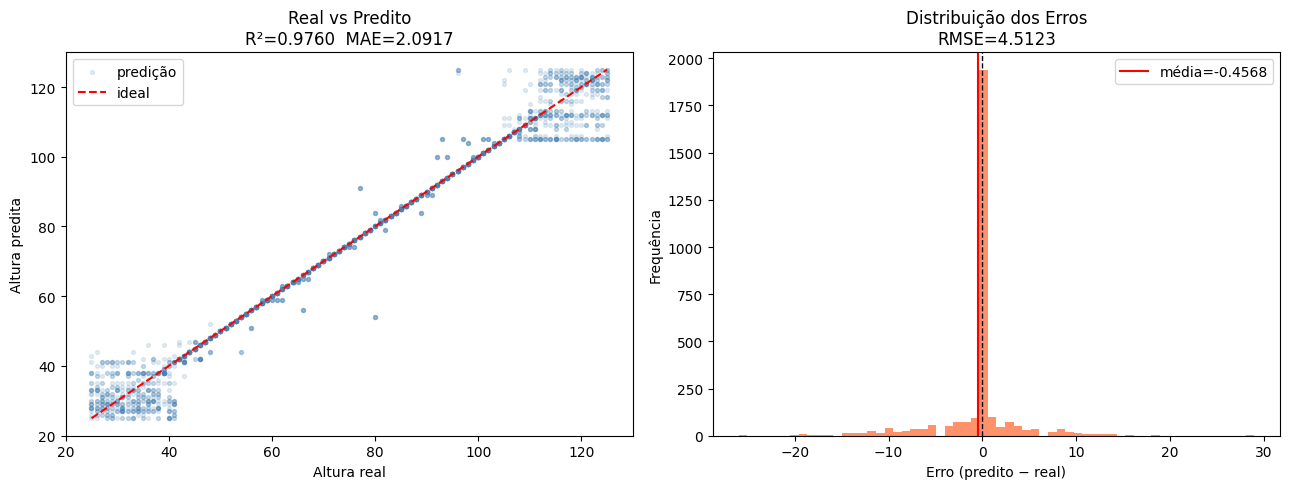

In [8]:
# Scatter: valor real vs predito
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter real vs predito ---
ax = axes[0]
ax.scatter(y_art, y_pred, alpha=0.15, s=8, color='steelblue', label='predição')
lims = [y_art.min(), y_art.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='ideal')
ax.set_xlabel('Altura real')
ax.set_ylabel('Altura predita')
ax.set_title(f'Real vs Predito\nR²={r2:.4f}  MAE={mae:.4f}')
ax.legend()

# --- Histograma dos erros ---
erros = y_pred - y_art
ax = axes[1]
ax.hist(erros, bins=60, edgecolor='none', color='coral', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(erros.mean(), color='red', linestyle='-',
           linewidth=1.5, label=f'média={erros.mean():.4f}')
ax.set_xlabel('Erro (predito − real)')
ax.set_ylabel('Frequência')
ax.set_title(f'Distribuição dos Erros\nRMSE={rmse:.4f}')
ax.legend()

plt.tight_layout()
plt.show()

## 7. Análise por Altura (Classe)

Avaliamos separadamente o desempenho para cada valor de altura, identificando
quais alturas são mais difíceis de estimar com os dados ruidosos.

In [9]:
# Métricas por altura
per_height = []
for h in unique_heights:
    mask = y_art == h
    yt = y_art[mask]
    yp = y_pred[mask]
    mae_h  = metrics.mean_absolute_error(yt, yp)
    rmse_h = np.sqrt(metrics.mean_squared_error(yt, yp))
    # acurácia exata: % de predições idênticas ao rótulo real
    acc_h  = np.mean(yp == yt)
    per_height.append({'height': h, 'n': mask.sum(), 'MAE': mae_h,
                        'RMSE': rmse_h, 'acc_exata': acc_h})

df_ph = pd.DataFrame(per_height)
print('Métricas por valor de altura:')
print(df_ph.to_string(index=False, float_format=lambda x: f'{x:.5f}'))

Métricas por valor de altura:
   height  n     MAE     RMSE  acc_exata
 25.00000 30 6.90000  8.26035    0.03333
 26.00000 30 5.63333  7.14376    0.06667
 27.00000 30 4.63333  6.30608    0.06667
 28.00000 30 3.73333  5.40370    0.10000
 29.00000 30 4.86667  6.27694    0.10000
 30.00000 30 3.76667  5.03653    0.16667
 31.00000 30 3.26667  4.06612    0.16667
 32.00000 30 4.43333  5.22494    0.06667
 33.00000 30 4.30000  5.25040    0.16667
 34.00000 30 4.43333  4.87511    0.00000
 35.00000 30 4.53333  5.33542    0.10000
 36.00000 30 5.23333  6.00278    0.03333
 37.00000 30 4.90000  5.73004    0.10000
 38.00000 30 5.80000  7.26177    0.26667
 39.00000 30 1.73333  3.02214    0.20000
 40.00000 30 8.50000 10.16038    0.10000
 41.00000 30 8.13333 10.26970    0.30000
 42.00000 30 0.30000  1.16905    0.93333
 43.00000 30 0.90000  1.60208    0.60000
 44.00000 30 0.10000  0.54772    0.96667
 45.00000 30 0.53333  1.12546    0.76667
 46.00000 30 1.33333  2.30940    0.66667
 47.00000 30 0.00000  0.000

Acurácia exata global (predição == valor real): 0.6389 (63.89%)


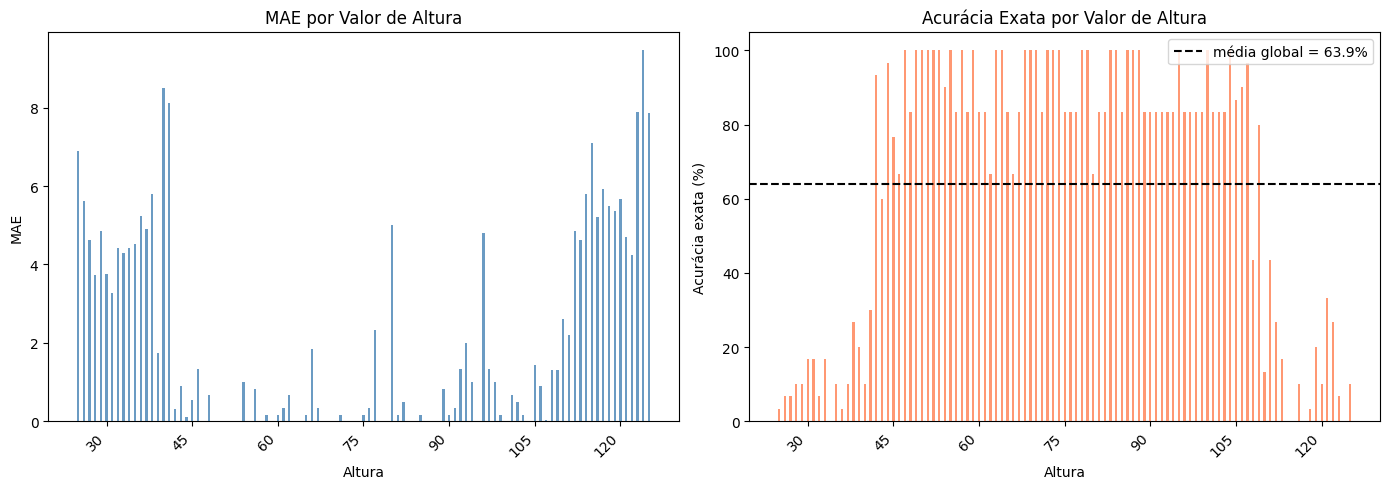

In [10]:
# Acurácia exata por altura (% de acerto quando se arredonda a predição)
# A acurácia exata faz sentido pois as alturas são valores discretos
overall_acc = np.mean(y_pred == y_art)
print(f'Acurácia exata global (predição == valor real): {overall_acc:.4f} ({overall_acc*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE por altura
ax = axes[0]
ax.bar(df_ph['height'], df_ph['MAE'], width=0.4, color='steelblue', alpha=0.8)
ax.set_xlabel('Altura')
ax.set_ylabel('MAE')
ax.set_title('MAE por Valor de Altura')
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10, integer=False))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Acurácia exata por altura
ax = axes[1]
ax.bar(df_ph['height'], df_ph['acc_exata'] * 100, width=0.4, color='coral', alpha=0.8)
ax.axhline(overall_acc * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'média global = {overall_acc*100:.1f}%')
ax.set_xlabel('Altura')
ax.set_ylabel('Acurácia exata (%)')
ax.set_title('Acurácia Exata por Valor de Altura')
ax.set_ylim(0, 105)
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10, integer=False))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 8. Comparação: Dados Originais vs Dados Artificiais Ruidosos

Avaliamos o modelo também nos dados originais (sem ruído) para referência.

In [11]:
# Predição nos dados originais
X_orig_scaled = scaler.transform(X_orig)
y_pred_orig   = knn.predict(X_orig_scaled)

mae_orig  = metrics.mean_absolute_error(y_orig, y_pred_orig)
rmse_orig = np.sqrt(metrics.mean_squared_error(y_orig, y_pred_orig))
r2_orig   = metrics.r2_score(y_orig, y_pred_orig)
acc_orig  = np.mean(y_pred_orig == y_orig)

print('=' * 50)
print('Comparação: Original vs Artificial (ruidoso)')
print('=' * 50)
print(f'{"Métrica":<12} {"Original":>12} {"Artificial":>12}')
print('-' * 50)
print(f'{"MAE":<12} {mae_orig:>12.6f} {mae:>12.6f}')
print(f'{"RMSE":<12} {rmse_orig:>12.6f} {rmse:>12.6f}')
print(f'{"R²":<12} {r2_orig:>12.6f} {r2:>12.6f}')
print(f'{"Acc exata":<12} {acc_orig:>12.4f} {overall_acc:>12.4f}')
print('=' * 50)

Comparação: Original vs Artificial (ruidoso)
Métrica          Original   Artificial
--------------------------------------------------
MAE              0.564356     2.091749
RMSE             2.490245     4.512323
R²               0.992704     0.976046
Acc exata          0.8762       0.6389


## 9. Conclusões

- **Dataset artificial**: gerado com ruído multiplicativo gaussiano $\mathcal{N}(1, 0.002)$, produzindo perturbações da ordem de **0.2%** em cada canal de medição.
- **Modelo KNN (k=1)**: treinado nos dados originais e avaliado nos dados artificiais.
- As métricas acima quantificam a degradação de desempenho causada pelo ruído sintético.
- Um **R² próximo de 1** e **MAE baixo** indicam que o modelo é robusto ao nível de ruído simulado.
- A coluna **acurácia exata** mede a fração de casos em que o KNN recupera exatamente o valor de altura correto — métrica especialmente relevante porque as alturas são valores discretos.